# Yield Simulator for D2W Hybrid Bonding
#### Author: Zhichao Chen
#### Date: Oct 23, 2025
#### Description: YAP+ESD-Stress (pad-layout-aware yield analysis)

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from utils.util import *
import time
import matplotlib.pyplot as plt
from assembly_yield_simulator import Assembly_Yield_Simulator
from spatial_correlation_coefficients_precalculate import Spatial_Correlation_Coefficients_Precalculate

In [26]:
# Load configuration
cfg = load_modeling_config(path='configs/HBM_footprint_B_config.yaml', 
                     mode='d2w_simulation',
                     debug=False)

# Generate pad bitmap collection
pad_bitmap_collection = convert_3dblox_to_pad_bitmap(cfg=cfg,
                                                     blox_bmap_path='input/' + cfg.DESIGN + '.bmap',
                                                     pad_arrange_pattern=cfg.PAD_ARRANGE_PATTERN)

start_time = time.time()

# Update above parameters in the configuration
update_config_items(cfg=cfg, mode='d2w_simulation')
cfg.NUM_DIES = 5  # For correlation coefficient precalculation, only 1 die is needed
cfg.SYSTEM_ROTATION_MEAN_rad = 7e-4
cfg.TOP_DISH_MEAN_nm = -0.0 
cfg.TOP_DISH_STD_nm = 0.3 
cfg.BOT_DISH_MEAN_nm = -0.0
cfg.BOT_DISH_STD_nm = 0.3 
cfg.D0 = 1e-7
Spatial_Correlation_Coefficients_Precalculate(
    cfg=cfg,
    pad_bitmap_collection=pad_bitmap_collection,                                               
)

Criticality file saved in  output/HBM_footprint_B/HBM_footprint_B_criticality.txt
Dishing bound calculation time: 0.71 seconds
Starting correlation calculation round 1/3...
Total 73671775 pad pairs found within distance range [65.19, 5000.00] um.
Processing die 0/5...
Starting correlation calculation round 2/3...
Total 79399916 pad pairs found within distance range [5000.00, 10000.00] um.
Processing die 0/5...
Starting correlation calculation round 3/3...
Total 13195039 pad pairs found within distance range [10000.00, 14998.03] um.
Processing die 0/5...
overlay correlation statistics saved in output/HBM_footprint_B/overlay_pad_fail_correlation_stats.txt
particle correlation statistics saved in output/HBM_footprint_B/particle_pad_fail_correlation_stats.txt
stress correlation statistics saved in output/HBM_footprint_B/stress_pad_fail_correlation_stats.txt
esd correlation statistics saved in output/HBM_footprint_B/esd_pad_fail_correlation_stats.txt


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Simulation progress: 10000/10000 epochs completed.
Assembly Yield: 100.00%
Total time taken: 146.46 seconds


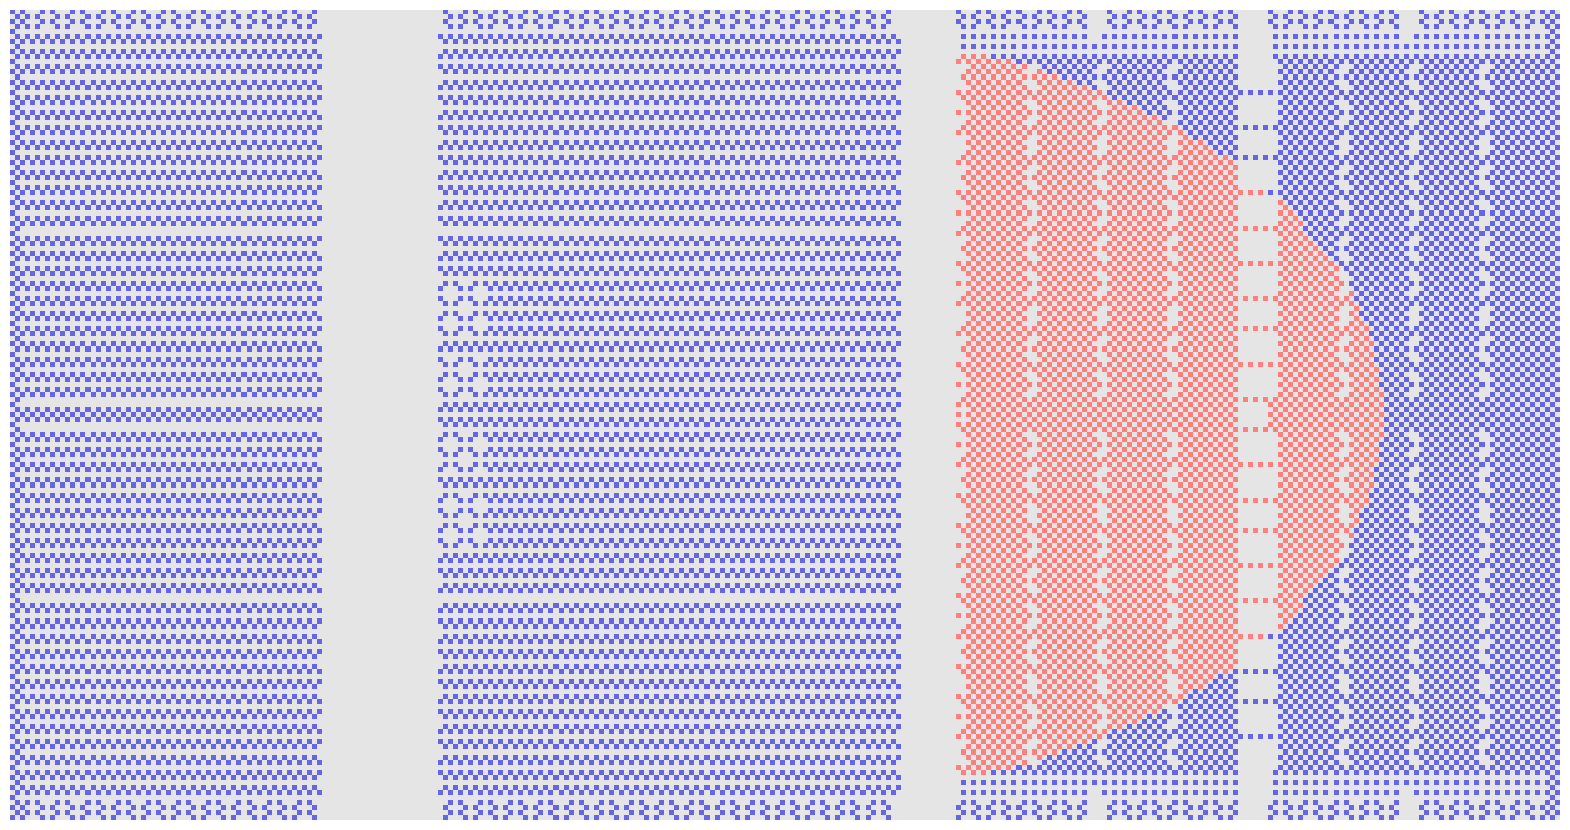

In [34]:
# Load configuration
cfg = load_modeling_config(path='configs/HBM_footprint_A_config.yaml', 
                     mode='d2w_simulation',
                     debug=False)

# Generate pad bitmap collection
# pad_bitmap_collection = convert_3dblox_to_pad_bitmap(cfg=cfg,
#                                                      blox_bmap_path='pad_bitmap/HBM_footprint_A.bmap', 
#                                                      pad_arrange_pattern='checkerboard')  
pad_bitmap_collection = convert_3dblox_to_pad_bitmap(cfg=cfg,
                                                    #  blox_bmap_path=cfg.INPUT_DIR + cfg.DESIGN + '.bmap',
    blox_bmap_path=cfg.INPUT_DIR + 'HBM_footprint_A_2.5D_output.bmap',
    criticality_path=cfg.INPUT_DIR + 'HBM_footprint_A_2.5D_criticality.txt',
    pad_arrange_pattern=cfg.PAD_ARRANGE_PATTERN)

start_time = time.time()

# Update above parameters in the configuration
update_config_items(cfg=cfg, mode='d2w_simulation')

assembly_yield, single_config_yield_list = Assembly_Yield_Simulator(
    cfg=cfg,
    pad_bitmap_collection=pad_bitmap_collection,                                               
)
print("\nAssembly Yield: {:.2f}%".format(assembly_yield * 100))
    
print("Total time taken: {:.2f} seconds".format(time.time() - start_time))

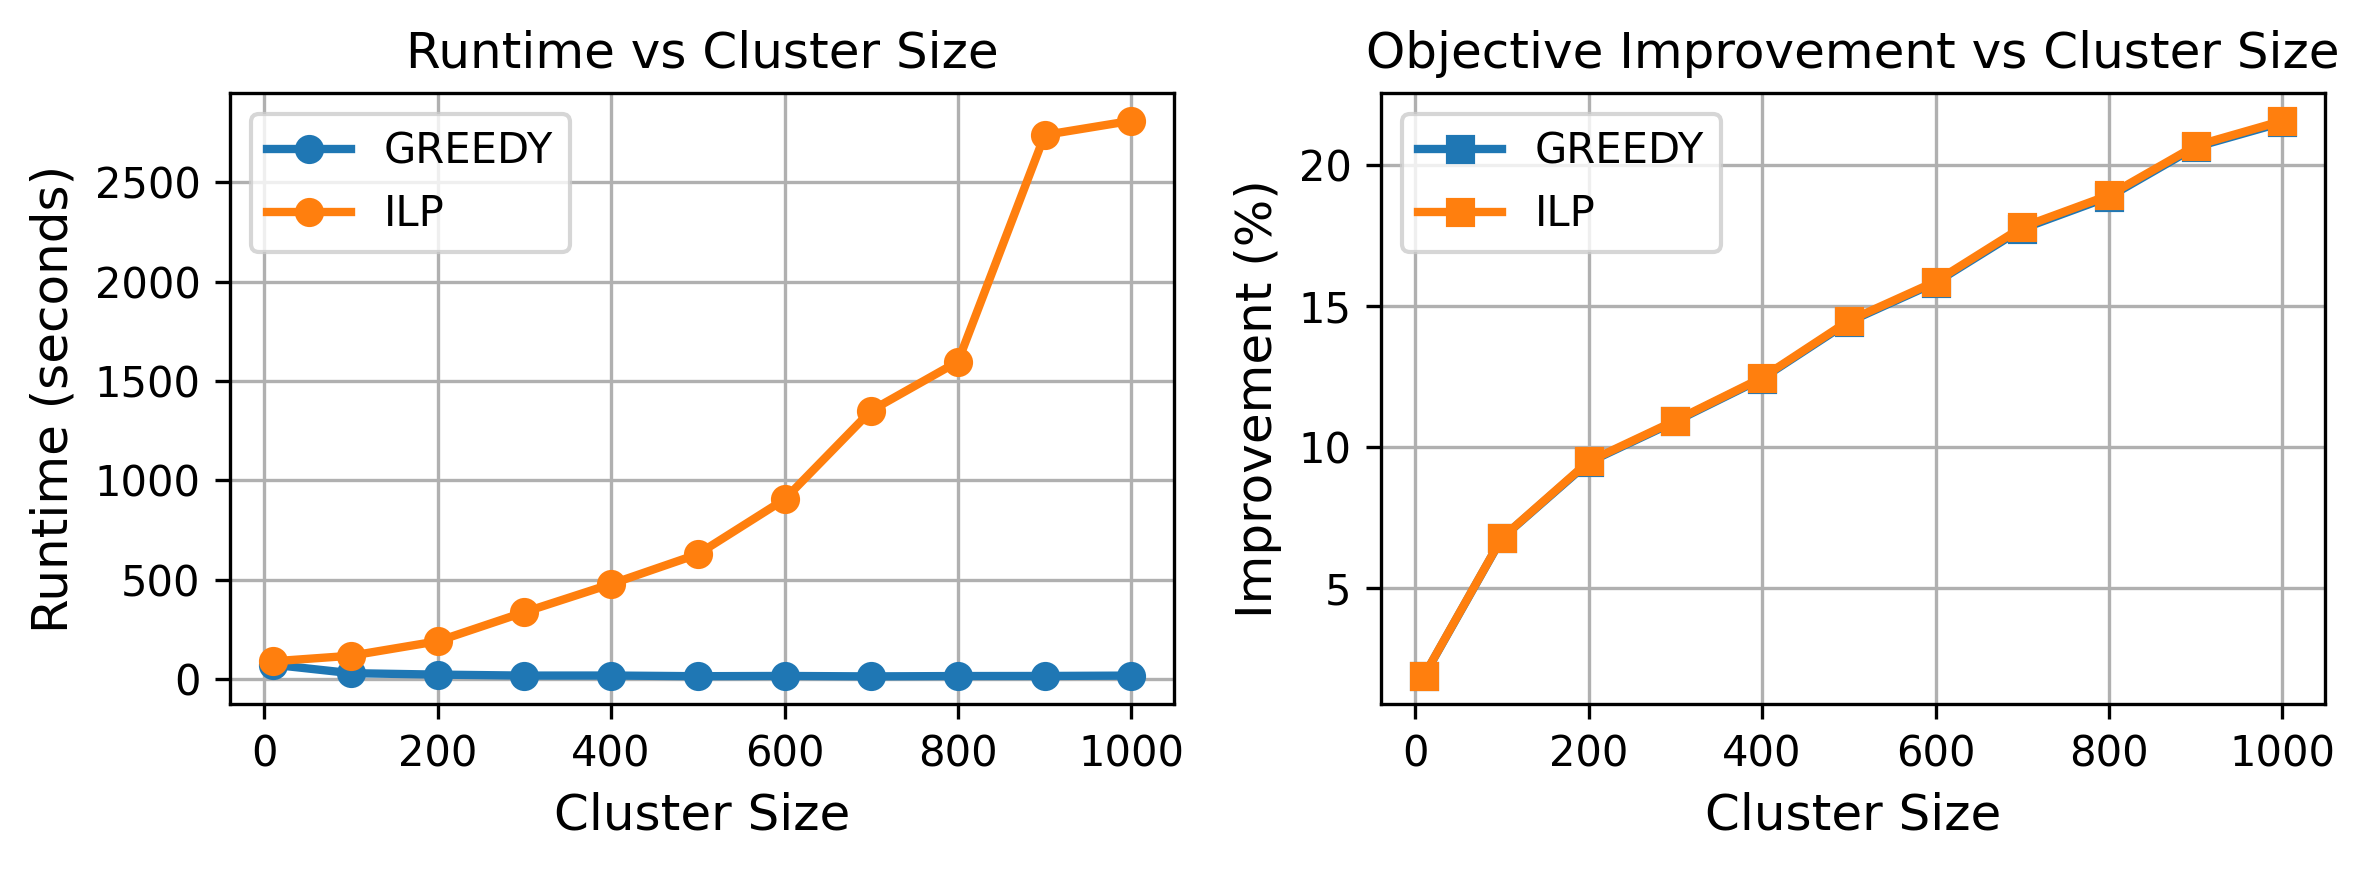

In [19]:
import matplotlib.pyplot as plt

# Data
cluster_sizes = [10,100,200,300,400,500,600,700,800,900,1000]

greedy_runtime = [72.58,29.92,22.65,17.69,18.02,14.58,15.84,13.68,15.37,15.75,17.72]
greedy_impr    = [1.88,6.78,9.47,10.92,12.44,14.45,15.84,17.75,18.88,20.65,21.52]

ilp_runtime    = [89.39,117.46,190.49,336.75,478.24,628.34,904.04,1351.12,1597.33,2737.16,2808.51]
ilp_impr       = [1.89,6.79,9.50,10.95,12.47,14.49,15.88,17.81,18.94,20.70,21.58]

# Create figure
fig, axs = plt.subplots(1, 2, figsize=(8, 3), dpi=300)

# ==============================
# Runtime plot
# ==============================
axs[0].plot(cluster_sizes, greedy_runtime, marker='o', label='GREEDY', linewidth=2)
axs[0].plot(cluster_sizes, ilp_runtime, marker='o', label='ILP', linewidth=2)

axs[0].set_title("Runtime vs Cluster Size", fontsize=12)
axs[0].set_xlabel("Cluster Size", fontsize=12)
axs[0].set_ylabel("Runtime (seconds)", fontsize=12)
axs[0].tick_params(axis='both', labelsize=10)
axs[0].legend()
axs[0].grid(True)

# ==============================
# Improvement plot
# ==============================

axs[1].plot(cluster_sizes, greedy_impr, marker='s', label='GREEDY', linewidth=2)
axs[1].plot(cluster_sizes, ilp_impr, marker='s', label='ILP', linewidth=2)

axs[1].set_title("Objective Improvement vs Cluster Size", fontsize=12)
axs[1].set_xlabel("Cluster Size", fontsize=12)
axs[1].set_ylabel("Improvement (%)", fontsize=12)
axs[1].tick_params(axis='both', labelsize=10)
axs[1].legend()
axs[1].grid(True)




plt.tight_layout()
plt.show()
